<a href="https://colab.research.google.com/github/shaipshiverya/Data_Analysis_python_projects/blob/main/data_science_gold_prediction_project_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importing the Dependencies

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics

# Data Collection and Processing

In [ ]:
df = pd.read_csv('/content/gld_price_data.csv')
df.head()

,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.180,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.285,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.167,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.053,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.590,1.557099


In [ ]:
# number of rows and columns

df.shape

(2290, 6)

In [ ]:
# getting some basic informations about the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     2290 non-null   object 
 1   SPX      2290 non-null   float64
 2   GLD      2290 non-null   float64
 3   USO      2290 non-null   float64
 4   SLV      2290 non-null   float64
 5   EUR/USD  2290 non-null   float64
dtypes: float64(5), object(1)
memory usage: 107.5+ KB


In [ ]:
# checking the number of missing values
df.isna().sum()

,0
Date,0
SPX,0
GLD,0
USO,0
SLV,0
EUR/USD,0


In [ ]:
# getting the statistical measures of the data
df.describe()

,SPX,GLD,USO,SLV,EUR/USD
count,2290.000000,2290.000000,2290.000000,2290.000000,2290.000000
mean,1654.315776,122.732875,31.842221,20.084997,1.283653
std,519.111540,23.283346,19.523517,7.092566,0.131547
min,676.530029,70.000000,7.960000,8.850000,1.039047
25%,1239.874969,109.725000,14.380000,15.570000,1.171313
50%,1551.434998,120.580002,33.869999,17.268500,1.303297
75%,2073.010070,132.840004,37.827501,22.882500,1.369971
max,2872.870117,184.589996,117.480003,47.259998,1.598798


In [ ]:
correlation = df.drop('Date',axis= 1).corr()

<Axes: >

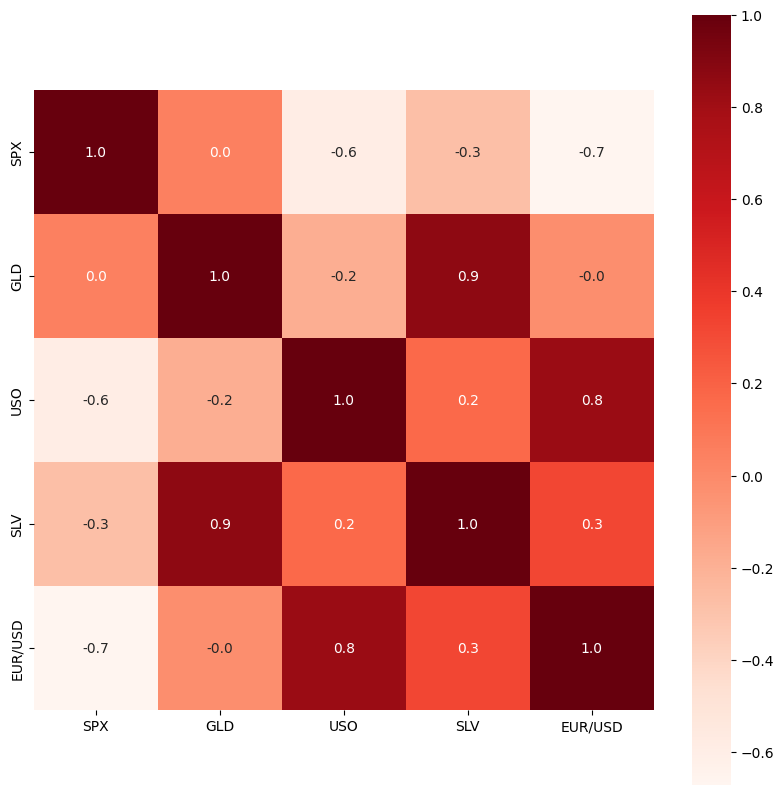

In [ ]:
plt.figure(figsize=(10,10))
sns.heatmap(correlation, cbar = True,square=True ,fmt = '0.1f', annot = True,cmap='Reds')

<Axes: xlabel='GLD', ylabel='Density'>

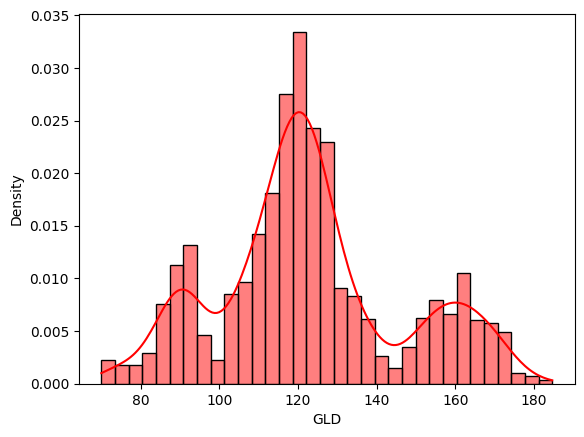

In [ ]:
# checking the distribution of the GLD Price
sns.histplot(df['GLD'],color='Red',kde = True, stat="density" )


# Splitting the Features and Target

In [ ]:
x = df.drop(['Date','GLD'], axis = 1)
y = df['GLD']

In [ ]:
print(x)
print(y)

              SPX        USO      SLV   EUR/USD
0     1447.160034  78.470001  15.1800  1.471692
1     1447.160034  78.370003  15.2850  1.474491
2     1411.630005  77.309998  15.1670  1.475492
3     1416.180054  75.500000  15.0530  1.468299
4     1390.189941  76.059998  15.5900  1.557099
...           ...        ...      ...       ...
2285  2671.919922  14.060000  15.5100  1.186789
2286  2697.790039  14.370000  15.5300  1.184722
2287  2723.070068  14.410000  15.7400  1.191753
2288  2730.129883  14.380000  15.5600  1.193118
2289  2725.780029  14.405800  15.4542  1.182033

[2290 rows x 4 columns]
0        84.860001
1        85.570000
2        85.129997
3        84.769997
4        86.779999
           ...    
2285    124.589996
2286    124.330002
2287    125.180000
2288    124.489998
2289    122.543800
Name: GLD, Length: 2290, dtype: float64


# Splitting into Training data and Test Data

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2 , random_state=3)

In [ ]:
print(x_train.shape , y_train.shape)

(1832, 4) (1832,)


# Model Training: Random Forest Regressor

In [ ]:
model = RandomForestRegressor(n_estimators=100)

In [ ]:
# training the model

model.fit(x_train,y_train)

RandomForestRegressor()

# Model Evaluation

In [ ]:
# prediction on Test Data
prediction = model.predict(x_test)

In [ ]:
print(prediction)

[163.53780112 127.52889917 124.22729943 119.67839893 126.17229898
  86.08819806 171.71860185 137.17889989 106.75620062 132.8518014
 120.5298993  124.77750054 143.42839896 104.56680013  80.77349899
 119.85950021 140.44670004  90.09100107  91.47849944 128.25340202
 125.71329919 147.99469939 116.56250143 153.62339937 129.48209922
 129.81730108 118.23850111 111.4125005  169.06060224 156.63569838
 125.92500182 154.0441011  127.05119935 122.69709783 116.51920131
 154.75280017 115.11479994 120.62710126 104.08650201 105.38120045
 135.08689932  85.80639973 155.08160128 121.49399999 122.36420082
 155.36010095 120.55040016 116.60370008 168.90740291 116.53130065
 137.99910205 161.61519879 157.99740135 153.26420039 124.1779003
 116.73359995 166.92460075 117.24259987 165.80820005  84.35900003
 121.40239911 122.18950019 119.81840044 172.00489837 118.87760005
 180.53359705 161.04710222 138.40520221 115.49540007  92.58850059
 171.94339923 117.61480022 117.5981986  125.65819983 147.03170045
  91.0649008

In [ ]:
# R squared error

error_score = metrics.r2_score(y_test,prediction)
print('R_squared_error : ',error_score)

R_squared_error :  0.9865894695543677


# Compare the Actual Values and Predicted Values in a Plot

In [ ]:
y_test = list(y_test)

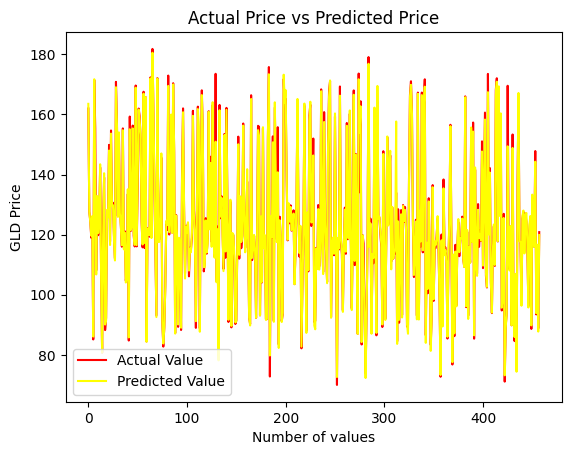

In [ ]:
plt.plot(y_test, color='red', label = 'Actual Value')
plt.plot(prediction, color='yellow', label='Predicted Value')
plt.title('Actual Price vs Predicted Price')
plt.xlabel('Number of values')
plt.ylabel('GLD Price')
plt.legend()
plt.show()